In [15]:
import numpy as np
import matplotlib.pyplot as plt
import cupy as cp
from cupyx.scipy.sparse import coo_matrix
from cupyx.scipy.sparse.linalg import eigsh
from scipy.optimize import curve_fit
import seaborn as sns
import tqdm
from tqdm import tqdm

In [16]:
J = -1

In [17]:
def eps(q, h):
  if isinstance(h, cp.ndarray):
    h = np.repeat(h, len(q))
  return ((h - np.cos(q))**2 + np.sin(q)**2)**.5

In [18]:
print(eps(0, 1))

0.0


In [19]:
def exact_eigs(N, h):
  gamma_even_fermions = np.array([2 * np.pi / N * (k + .5) for k in range(N)])
  gamma_odd_fermions = np.array([2 * np.pi / N * (k) for k in range(N)])
  E_bar_even_fermions = -.5 * np.sum(eps(gamma_even_fermions, h))
  E_bar_odd_fermions = -.5 * np.sum(eps(gamma_odd_fermions, h))
  GS_even_fermions = E_bar_even_fermions
  if h <= 1:
    GS_odd_fermions = E_bar_odd_fermions
  else:
    GS_odd_fermions = E_bar_odd_fermions + eps(0, h)

  return GS_even_fermions, GS_odd_fermions


In [20]:
def bit(j, n):
  return int((n & (1 << j)) != 0)

In [21]:
def bitsum(N, n):
  return sum(2 * bit(j, n) - 1 for j in range(N))

In [22]:
import cupy as cp
from cupyx.scipy.sparse import coo_matrix

def H_total(N, h, J= -1):
  basis_even, basis_odd = [], []

  for n in range(2**N):
    zeros = N - n.bit_count()
    if zeros % 2 == 0:
        basis_even.append(n)
    else:
        basis_odd.append(n)

  map_even = {state: i for i, state in enumerate(basis_even)}
  map_odd  = {state: i for i, state in enumerate(basis_odd)}

  rows_e, cols_e, data_e = [], [], []
  rows_o, cols_o, data_o = [], [], []

  for n in range(2**N):
    ones = n.bit_count()
    zeros = N - ones
    H_field = .5 * J * h * (ones - zeros)
    H_interaction = .5 * J
    if n in map_even:
      i = map_even[n]
      rows_e.append(i)
      cols_e.append(i)
      data_e.append(H_field)
      for j in range(N):
        m = n ^ (1 << j) ^ (1 << ((j+1) % N))
        k = map_even[m]
        rows_e.append(i)
        cols_e.append(k)
        data_e.append(H_interaction)
    else:
      i = map_odd[n]
      rows_o.append(i)
      cols_o.append(i)
      data_o.append(H_field)
      for j in range(N):
        m = n ^ (1 << j) ^ (1 << ((j+1) % N))
        k = map_odd[m]
        rows_o.append(i)
        cols_o.append(k)
        data_o.append(H_interaction)

  He = coo_matrix((cp.array(data_e), (cp.array(rows_e), cp.array(cols_e))),
                  shape=(len(basis_even), len(basis_even)))
  Ho = coo_matrix((cp.array(data_o), (cp.array(rows_o), cp.array(cols_o))),
                  shape=(len(basis_odd), len(basis_odd)))

  return He, Ho


In [23]:
def FirstTwoStates(N, h):
  H_even, H_odd = H_total(N, h)
  eigs_even = (eigsh(H_even, k = 2, which = 'SA', return_eigenvectors = False))
  eigs_odd = (eigsh(H_odd, k = 2, which = 'SA', return_eigenvectors = False))
  eigs_tot = cp.sort(np.append(eigs_even, eigs_odd))
  gs_truth, i_truth = exact_eigs(N, h)
  return eigs_tot[0], eigs_tot[1], gs_truth, i_truth

In [24]:
def fit_func(x, a, b):
    return a * x**b

In [25]:
def linear(x, m, q):
  return m * x + q

In [26]:
def get_results(Nmax, Nmin, h = 1):
  E_0 = cp.empty(0)
  E_1 = cp.empty(0)
  E_0_truth = cp.empty(0)
  E_1_truth = cp.empty(0)
  Ns = np.arange(Nmin, Nmax + 1)
  for N in tqdm(Ns):
    e_0, e_1, e_0_truth, e_1_truth = FirstTwoStates(N, 1)
    E_0 = cp.append(E_0, e_0)
    E_1 = cp.append(E_1, e_1)
    E_0_truth = cp.append(E_0_truth, e_0_truth)
    E_1_truth = cp.append(E_1_truth, e_1_truth)

    E_0_cpu = E_0.get()
    E_1_cpu = E_1.get()
    E_0_truth_cpu = E_0_truth.get()
    E_1_truth_cpu = E_1_truth.get()
    delta_cpu = E_1_cpu - E_0_cpu
    delta_truth_cpu = E_1_truth_cpu - E_0_truth_cpu

    error_0 = (E_0_cpu - E_0_truth_cpu) / E_0_truth_cpu
    error_1 = (E_1_cpu - E_1_truth_cpu) / E_1_truth_cpu
    error_delta = (delta_cpu - delta_truth_cpu) / delta_truth_cpu

  return delta_cpu, error_0, error_1, error_delta

In [27]:
def sample_results(Nmax, Nmin, h=1, n_samples=4):
    delta_sim, error_gs, error_1exc, error_delta = [], [], [], []

    for _ in tqdm(range(n_samples)):
        delta_sim_temp, error_gs_temp, error_1exc_temp, error_delta_temp = get_results(Nmax, Nmin, h)
        delta_sim.append(delta_sim_temp)
        error_gs.append(error_gs_temp)
        error_1exc.append(error_1exc_temp)
        error_delta.append(error_delta_temp)

    delta_sim = np.array(delta_sim)
    error_gs = np.array(error_gs)
    error_1exc = np.array(error_1exc)
    error_delta = np.array(error_delta)

    return (
        delta_sim.mean(axis=0), delta_sim.std(axis=0, ddof=1),
        error_gs.mean(axis=0), error_gs.std(axis=0, ddof=1),
        error_1exc.mean(axis=0), error_1exc.std(axis=0, ddof=1),
        error_delta.mean(axis=0), error_delta.std(axis=0, ddof=1)
    )


In [28]:
Nmin = 6
Nmax = 15
n_samples = 1
delta_sim, error_gs, error_1exc, error_delta = get_results(Nmax, Nmin, h = 1)

100%|██████████| 10/10 [00:11<00:00,  1.16s/it]


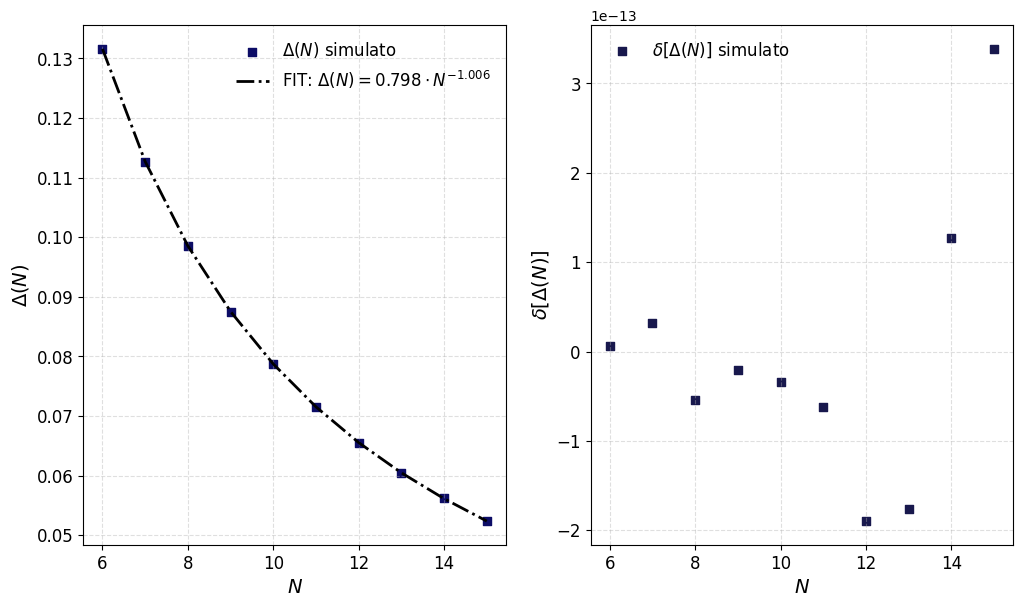

In [29]:
Ns = np.arange(Nmin, Nmax + 1)
fit_params, fot_params_cov = curve_fit(fit_func, Ns, delta_sim)

imscale = .75
fig, axs = plt.subplots(1, 2, figsize = (16 * imscale, 9 * imscale))
colors = sns.dark_palette("navy", n_colors = 4)

axs[0].scatter(
    Ns, delta_sim,
    color = colors[2], marker = 's', s = 30,
    label = r'$\Delta(N)$ simulato'
)
axs[0].plot(
    Ns, fit_func(Ns, *fit_params),
    color = 'black', ls = '-.', linewidth = 2,
    label = fr'FIT: $\Delta(N) = {np.round(fit_params[0], 3)} \cdot N^{{{np.round(fit_params[1], 3)}}}$'
)
axs[0].set_xlabel(r'$N$', fontsize = 14)
axs[0].set_ylabel(r'$\Delta(N)$', fontsize = 14)
axs[0].tick_params(axis = 'both', which = 'major', labelsize = 12)
axs[0].legend(fontsize = 12, frameon = False)
axs[0].grid(True, alpha = .4, linestyle = '--')

axs[1].scatter(
    Ns, error_delta, color = colors[1],
    marker = 's', s = 30,
    label = r'$\delta[\Delta(N)]$ simulato'
)
axs[1].set_xlabel(r'$N$', fontsize = 14)
axs[1].set_ylabel(r'$\delta[\Delta(N)]$', fontsize = 14)
axs[1].tick_params(axis = 'both', which = 'major', labelsize = 12)
axs[1].legend(fontsize = 12, frameon = False)
axs[1].grid(True, alpha = .4, linestyle = '--')

plt.savefig('delta.pdf')